In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

###Load DataSet

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # Normalizes with MNIST mean & std
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.10MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 905kB/s]


###Image Visuals

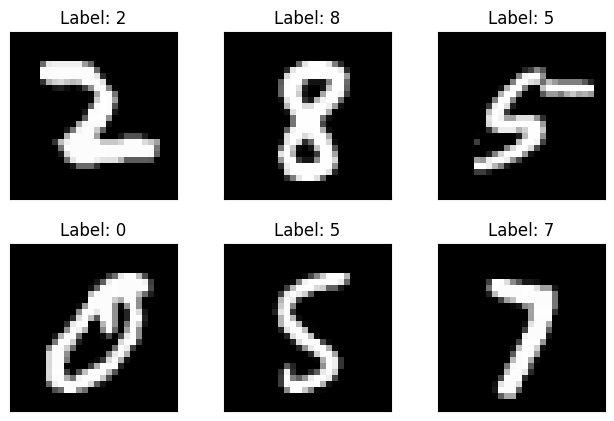

In [3]:
examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig = plt.figure()
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    plt.title("Label: {}".format(example_targets[i]))
    plt.xticks([])
    plt.yticks([])
plt.show()

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.dropout1 = nn.Dropout2d(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))  # [batch, 32, 26, 26]
        x = F.relu(self.conv2(x))  # [batch, 64, 24, 24]
        x = F.max_pool2d(x, 2)     # [batch, 64, 12, 12]
        x = self.dropout1(x)
        x = torch.flatten(x, 1)    # Flatten all but batch
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [5]:
# !pip install torchsummary

### Instantiate model, define optimizer and loss

In [6]:
#GPU significantly speeds up tensor ops; fall back to CPU if unavailable
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# move model parameters to GPU memory if available, else keep on CPU
model = CNN().to(device)

#Adam adapts learning rate per parameter
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
from torchsummary import summary
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             320
            Conv2d-2           [-1, 64, 24, 24]          18,496
         Dropout2d-3           [-1, 64, 12, 12]               0
            Linear-4                  [-1, 128]       1,179,776
           Dropout-5                  [-1, 128]               0
            Linear-6                   [-1, 10]           1,290
Total params: 1,199,882
Trainable params: 1,199,882
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.52
Params size (MB): 4.58
Estimated Total Size (MB): 5.10
----------------------------------------------------------------


## Training Loop

In [8]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f"Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}]  Loss: {loss.item():.6f}")

##Test Loop

In [9]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)

    print(f"\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n")

##Start The training and testing

In [10]:
for epoch in range(1, 6):
    train(model, device, train_loader, optimizer, epoch)
    test(model, device, test_loader)

Train Epoch: 1 [0/60000]  Loss: 2.307791
Train Epoch: 1 [6400/60000]  Loss: 0.434252
Train Epoch: 1 [12800/60000]  Loss: 0.078401
Train Epoch: 1 [19200/60000]  Loss: 0.194310
Train Epoch: 1 [25600/60000]  Loss: 0.059308
Train Epoch: 1 [32000/60000]  Loss: 0.037750
Train Epoch: 1 [38400/60000]  Loss: 0.119656
Train Epoch: 1 [44800/60000]  Loss: 0.049079
Train Epoch: 1 [51200/60000]  Loss: 0.114894
Train Epoch: 1 [57600/60000]  Loss: 0.137626

Test set: Average loss: 0.0445, Accuracy: 9849/10000 (98.49%)

Train Epoch: 2 [0/60000]  Loss: 0.150791
Train Epoch: 2 [6400/60000]  Loss: 0.113439
Train Epoch: 2 [12800/60000]  Loss: 0.327717
Train Epoch: 2 [19200/60000]  Loss: 0.064333
Train Epoch: 2 [25600/60000]  Loss: 0.059667
Train Epoch: 2 [32000/60000]  Loss: 0.061413
Train Epoch: 2 [38400/60000]  Loss: 0.033644
Train Epoch: 2 [44800/60000]  Loss: 0.044367
Train Epoch: 2 [51200/60000]  Loss: 0.041750
Train Epoch: 2 [57600/60000]  Loss: 0.151045

Test set: Average loss: 0.0364, Accuracy: 987

##Save the model

In [16]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 18.0 MB/s eta 0:00:00


In [17]:
import onnxruntime as ort
dummy_input = torch.randn(1, 1, 28, 28).to(device) #define expected tensor inputs for onnx
torch.save(model.state_dict(), "cnn_model_pytorch.pt")      #for training and later finetuning
torch.onnx.export(model, dummy_input, "cnn_model_pytorch.onnx") #for inference only without pytorch module

W0310 01:03:36.839000 503 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0310 01:03:36.843000 503 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0310 01:03:36.846000 503 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0310 01:03:36.851000 503 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"x"<FLOAT,[1,1,28,28]>
            ),
            outputs=(
                %"log_softmax"<FLOAT,[1,10]>
            ),
            initializers=(
                %"conv1.weight"<FLOAT,[32,1,3,3]>{TorchTensor(...)},
                %"conv1.bias"<FLOAT,[32]>{TorchTensor(...)},
                %"conv2.weight"<FLOAT,[64,32,3,3]>{TorchTensor(...)},
                %"conv2.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"fc1.weight"<FLOAT,[128,9216]>{TorchTensor(...)},
                %"fc1.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"fc2.weight"<FLOAT,[10,128]>{TorchTensor(...)},
                %"fc2.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Paramete

## Model Loading

In [20]:
loaded_model = CNN().to(device)
model_path = "cnn_model_pytorch.pt"
loaded_model.load_state_dict(torch.load(model_path))
loaded_model.eval()
print("Model loaded successfully.")

Model loaded successfully.


##Define prediction

In [21]:
def predict(model, device, data_loader, num_samples=6):
    model.eval()
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    images, labels = images.to(device), labels.to(device)
    output = model(images)
    preds = output.argmax(dim=1)

    # Visualize predictions
    fig = plt.figure()
    for i in range(num_samples):
        plt.subplot(2, 3, i + 1)
        plt.tight_layout()
        plt.imshow(images[i][0].cpu(), cmap='gray', interpolation='none')
        plt.title(f"Pred: {preds[i].item()}, Label: {labels[i].item()}")
        plt.xticks([])
        plt.yticks([])
    plt.show()

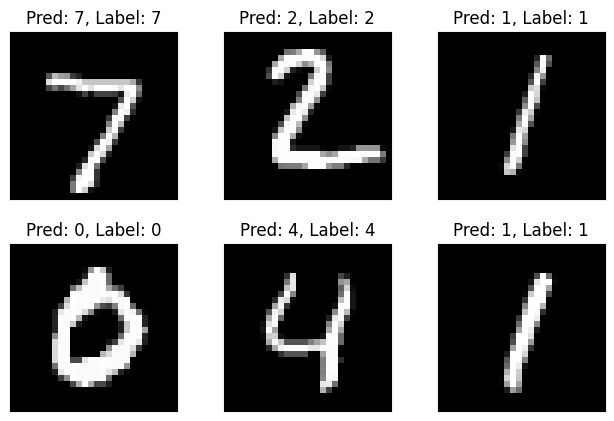

In [22]:
# Run prediction
predict(loaded_model, device, test_loader)

##Test accuracy

In [24]:
correct, total = 0, 0
loaded_model.eval()

with torch.no_grad():
  for data, target in test_loader:
    data, target = data.to(device), target.to(device)
    output = loaded_model(data)
    pred = output.argmax(dim=1)  # sabse high probability wala digit
    correct += pred.eq(target).sum().item()
    total += len(target)

print(f"Test Accuracy: {100. * correct / total:.2f}%")

Test Accuracy: 98.91%
